In [102]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Dict, List
from langgraph.types import Send
from langgraph.store.memory import InMemoryStore, BaseStore
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from operator import add 
import pprint


In [92]:
class State(TypedDict):
    opponent_stats: Dict 
    model_prediction: Annotated[List[Dict], add]
    # prediction_models: List[str] = ["random_forest", "xg-boost", "ada-boost"]
    historical_win_rate = float
    final_prediction : float

In [93]:
def load_historical_stats(state: State, store: BaseStore, config: RunnableConfig) -> State:
    knight_name = config["configurable"]["knight_id"]
    namespace = ("knight_data", knight_name)
    stats = store.get(namespace=namespace, key="record")
    if stats:
        wins = stats.value.get("wins", 0)
        total = wins + stats.value.get("loss", 0)
        baseline = wins / total if total > 0 else 0.5
    else:
        baseline = 0.5
    return {"historical_win_rate" : baseline}

In [94]:
def supervisor_node(state: State) -> List[Send]:
    prediction_models = ["random_forest", "xg-boost", "ada-boost"]
    return [
        Send(model, {"opponent_info": state["opponent_stats"]}) # Matched the key!
        for model in prediction_models
    ]

In [95]:
import random
def generate_sub_graph(algorithm: str):
    class subState(TypedDict):
        opponent_info = Dict 
        processed_data : Dict
        model_prediction: List[Dict]

    def data_preprocess_node(state: subState) -> subState:
        print("Data Preprocessing done")
        processed_data = state #just for dummy usage
        return {"processed_data" : processed_data}

    def prediction_node(state: subState) -> dict:
        print(f"making prediciton via {algorithm}")
        prediction = [0.9, 0.4, 0.5, 0.7]
        return {"model_prediction" : [{"model" : algorithm, "prediction" : random.choice(prediction)}]}

    builder = StateGraph(subState)
    builder.add_node("preprocess", data_preprocess_node)
    builder.add_node("pred", prediction_node)

    builder.add_edge(START, "preprocess")
    builder.add_edge("preprocess", "pred")
    builder.add_edge("pred", END)

    return builder.compile()

        

In [96]:
random_forest_graph = generate_sub_graph(algorithm="random_forest")
xg_boost_graph = generate_sub_graph(algorithm="xg-boost")
ada_boost_graph = generate_sub_graph(algorithm="ada-boost")

In [97]:
def reducer_node(state: State) -> State:
    model_predictions = state.get("model_prediction", [])
    avg = sum(m["prediction"] for m in model_predictions) / len(model_predictions)
    return {"final_prediction" : round(avg, 3)}

def check_node(state: State, config: RunnableConfig, store: BaseStore):
    final_prediction = state["final_prediction"]
    user_id = config["configurable"]["knight_id"]
    namespace = ("knight_data", user_id)
    record = store.get(namespace=namespace, key="record")
    wins = record.value.get("wins", 0) if record else 0
    if final_prediction > 0.7:
        store.put(namespace,"record", {"wins" : wins + 1})
    else:
        store.put(namespace,"record", {"loss" : wins + 1})
        print(f"Win ratio : {state["final_prediction"]}")
        raise ValueError("Model hyperparameter tuning required...")

In [98]:
builder = StateGraph(State)
store = InMemoryStore()
saver = InMemorySaver()

builder.add_node("load", load_historical_stats)
# builder.add_node("supervise", supervisor_node)
builder.add_node("random_forest", random_forest_graph)
builder.add_node("xg-boost", xg_boost_graph)
builder.add_node("ada-boost", ada_boost_graph)
builder.add_node("reduce", reducer_node)
builder.add_node("check", check_node)

builder.add_edge(START, "load")
builder.add_conditional_edges("load", supervisor_node, ["random_forest", "xg-boost", "ada-boost"])
builder.add_edge("random_forest", "reduce")
builder.add_edge("xg-boost", "reduce")
builder.add_edge("ada-boost", "reduce")
builder.add_edge("reduce", "check")
builder.add_edge("check", END)

graph = builder.compile(checkpointer=saver, store=store)

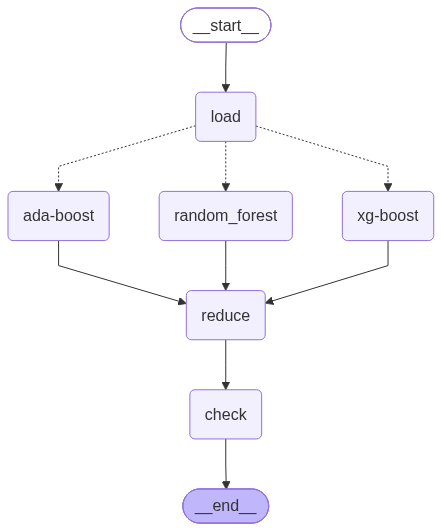

In [99]:
graph

In [104]:
config = {"configurable" : {
    "thread_id" : "001", "knight_id" : "Ser_duncan_the_tall"
}}
opp_stats = {"dummy_data" : "dummy"}

try:
    print("---FIRST RUN---")
    graph.invoke({"opponent_stats" : opp_stats}, config=config)
except ValueError as e:
    print(f"Execution Halted: {e}")
history = list(graph.get_state_history(config=config))

target_checkpoint = None
for i,state in enumerate(history):
    print(f"--- state {i} ---")
    pprint.pprint(state, indent=4, width=20)
    if state.next == ('random_forest', 'xg-boost', 'ada-boost'):
        target_checkpoint = state
        break 

print("--"*20)

if target_checkpoint:
    print(f"\nRewinding to checkpoint: {target_checkpoint.config['configurable']['checkpoint_id']}")
    forked_config = graph.update_state(
        target_checkpoint.config, {"opponent_stats": {"dummy_data": "dummy", "hyperparameters_tuned": True}}
    )
    print("---SECOND RUN---")
    try:
        for event in graph.stream(None, config=forked_config):
            print(event)
    except:
        print("Still failed! Needs more tuning.")

---FIRST RUN---
Data Preprocessing done
making prediciton via xg-boost
Data Preprocessing done
Data Preprocessing done
making prediciton via random_forest
making prediciton via ada-boost
--- state 0 ---
StateSnapshot(values={'opponent_stats': {'dummy_data': 'dummy'}, 'model_prediction': [{'model': 'random_forest', 'prediction': 0.9}, {'model': 'xg-boost', 'prediction': 0.5}, {'model': 'ada-boost', 'prediction': 0.7}, {'model': 'random_forest', 'prediction': 0.5}, {'model': 'xg-boost', 'prediction': 0.7}, {'model': 'ada-boost', 'prediction': 0.7}, {'model': 'random_forest', 'prediction': 0.7}, {'model': 'xg-boost', 'prediction': 0.4}, {'model': 'ada-boost', 'prediction': 0.9}, {'model': 'random_forest', 'prediction': 0.9}, {'model': 'xg-boost', 'prediction': 0.9}, {'model': 'ada-boost', 'prediction': 0.7}], 'final_prediction': 0.708}, next=(), config={'configurable': {'thread_id': '001', 'checkpoint_ns': '', 'checkpoint_id': '1f1aa9f5-aca7-63e4-8013-ee208ebad81a'}}, metadata={'source': 